# Anomaly Detection: Identifying Nutritionally Unusual Food Products

### AAI-590 Capstone Project - University of San Diego
### Team Members:
 - Jamshed Nabizada
 - Swapnil Patil

## Purpose

This notebook implements identifying nutritionally anomalous food products by measuring how much they deviate from a **whole-food baseline** (NOVA 1 - Unprocessed Foods).

All three anomaly models are trained **exclusively on NOVA 1 samples** from the training set. Products with high anomaly scores deviate significantly from what a whole food looks like nutritionally, independent of their NOVA classification tier.


## Environment Setup and Configuration

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# suppress warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

# force-reload src modules so code changes are always picked up
%load_ext autoreload
%autoreload 2

import json
import time
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from IPython.display import display

from src.modeling import (
    FEATURES_ARTIFACTS_DIRECTORY,
    NOVA_LABELS,
    RANDOM_STATE,
    MODEL_TRAINING_ARTIFACTS_DIRECTORY,
    MODEL_TUNING_ARTIFACTS_DIRECTORY,
    API_MODEL_RESULTS_DIRECTORY,
    ANOMALY_DETECTION_ARTIFACTS_DIRECTORY
)
from src.anomaly import (
    NOVA_COLORS,
    MODEL_COLORS,
    AnomalyTrainer,
    AnomalyScorer,
    AnomalyPlotter,
    predict_nova_and_anomaly,
)

np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

# shared instances used throughout the notebook
trainer = AnomalyTrainer(random_state=RANDOM_STATE)
scorer  = AnomalyScorer(ae_percentile=95)
plotter = AnomalyPlotter()

print("Environment ready.")

Environment ready.


## Load Data and Artifacts

Load the train/validation/test splits produced by the Feature Engineering notebook (Notebook 02), and the fitted StandardScaler. The **scaled** feature matrices are used for all anomaly models, because distance-based and kernel methods are sensitive to feature scale.

This notebook uses **15 features** total:
- **11 original nutritional features** selected from EDA
- **4 engineered ratio features** created in Feature Engineering

In [3]:
# load saved splits and metadata from Feature Engineering notebook (Notebook 02)
splits = joblib.load(FEATURES_ARTIFACTS_DIRECTORY / "data_splits.joblib")

# unscaled splits (used for feature inspection and the final inference function)
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

# scaled versions — used for all three anomaly detection models
X_train_scaled = splits["X_train_scaled"]
X_val_scaled   = splits["X_val_scaled"]
X_test_scaled  = splits["X_test_scaled"]

# feature names and the fitted scaler
feature_names = splits["feature_names"]
scaler        = joblib.load(FEATURES_ARTIFACTS_DIRECTORY / "standard_scaler.joblib")

# load feature engineering metadata to validate consistency
with open(FEATURES_ARTIFACTS_DIRECTORY / "feature_engineering_metadata.json") as f:
    fe_meta = json.load(f)

# validate feature consistency (11 original + 4 engineered = 15 total)
expected_num_features = len(fe_meta["original_features"]) + len(fe_meta["engineered_features"])
assert len(feature_names) == expected_num_features, \
    f"Feature count mismatch: expected {expected_num_features}, got {len(feature_names)}"
assert len(feature_names) == 15, \
    f"Expected 15 features (11 original + 4 engineered), got {len(feature_names)}"

print("Feature Engineering Metadata Validation")
print(f"Original features: {len(fe_meta['original_features'])}")
print(f"Engineered features: {len(fe_meta['engineered_features'])}")
print(f"Total features: {len(feature_names)}")
print(f"Removed from EDA: {', '.join(fe_meta['features_removed_in_eda'])}")

# combine train + val scaled data to give anomaly models more NOVA 1 examples
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval        = pd.concat([y_train, y_val], ignore_index=True)

# verify y values: nova labels are 0-indexed (0=NOVA1, 1=NOVA2, 2=NOVA3, 3=NOVA4)
print(f"\ny unique values: {sorted(y_test.unique())}  →  NOVA groups 1-4 (0-indexed)")
print(f"\nFeatures ({len(feature_names)}):")
for feat in feature_names:
    print(f"  - {feat}")
print(f"\nData Splits:")
print(f"  Train: {X_train.shape}   Val: {X_val.shape}   Test: {X_test.shape}")

Feature Engineering Metadata Validation
Original features: 11
Engineered features: 4
Total features: 15
Removed from EDA: sodium_100g, trans_fat_100g, monounsaturated_fat_100g, polyunsaturated_fat_100g, starch_100g

y unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  →  NOVA groups 1-4 (0-indexed)

Features (15):
  - energy_100g
  - fat_100g
  - carbohydrates_100g
  - sugars_100g
  - fiber_100g
  - proteins_100g
  - salt_100g
  - saturated_fat_100g
  - additives_n
  - added_sugars_100g
  - nutriscore_score
  - sugar_fiber_ratio
  - fat_protein_ratio
  - additives_per_energy
  - saturated_fat_ratio

Data Splits:
  Train: (134275, 15)   Val: (44758, 15)   Test: (44759, 15)


In [4]:
# ── Extract NOVA 1 (whole-food) training data ─────────────────────────────────
# All three anomaly models train ONLY on NOVA 1 samples.
# y == 0 corresponds to NOVA 1 (unprocessed foods) in the 0-indexed encoding.

nova1_mask_trainval = (y_trainval == 0)
nova1_mask_test     = (y_test == 0)

X_nova1_train = X_trainval_scaled[nova1_mask_trainval.values]  # training baseline
X_nova1_test  = X_test_scaled[nova1_mask_test.values]          # NOVA 1 test portion

print(f"NOVA 1 training samples (train + val combined): {X_nova1_train.shape[0]:,}")
print(f"NOVA 1 test samples:                            {X_nova1_test.shape[0]:,}")
print()

# split test set by NOVA group for per-group evaluation
for g in range(4):
    mask  = (y_test.values == g)
    count = mask.sum()
    pct   = count / len(y_test) * 100
    print(f"  NOVA {g+1} test: {count:,} samples ({pct:.1f}%)")

NOVA 1 training samples (train + val combined): 21,505
NOVA 1 test samples:                            5,377

  NOVA 1 test: 5,377 samples (12.0%)
  NOVA 2 test: 1,643 samples (3.7%)
  NOVA 3 test: 8,990 samples (20.1%)
  NOVA 4 test: 28,749 samples (64.2%)


---
## NOVA 1 Whole-Food Baseline Profile

Before training the anomaly models, we characterise the NOVA 1 distribution: this is the "normal" the detectors learn. Products that deviate sharply from these statistics will receive high anomaly scores.

In [5]:
# Extract NOVA 1 (whole-food) training data
# All three anomaly models train ONLY on NOVA 1 samples.
# y == 0 corresponds to NOVA 1 (unprocessed foods) in the 0-indexed encoding.

nova1_mask_trainval = (y_trainval == 0)
nova1_mask_test     = (y_test == 0)

X_nova1_train = X_trainval_scaled[nova1_mask_trainval.values]  # training baseline
X_nova1_test  = X_test_scaled[nova1_mask_test.values]          # NOVA 1 test portion

print(f"NOVA 1 training samples (train + val combined): {X_nova1_train.shape[0]:,}")
print(f"NOVA 1 test samples:                            {X_nova1_test.shape[0]:,}")
print()

# split test set by NOVA group for per-group evaluation
for g in range(4):
    mask  = (y_test.values == g)
    count = mask.sum()
    pct   = count / len(y_test) * 100
    print(f"  NOVA {g+1} test: {count:,} samples ({pct:.1f}%)")

NOVA 1 training samples (train + val combined): 21,505
NOVA 1 test samples:                            5,377

  NOVA 1 test: 5,377 samples (12.0%)
  NOVA 2 test: 1,643 samples (3.7%)
  NOVA 3 test: 8,990 samples (20.1%)
  NOVA 4 test: 28,749 samples (64.2%)


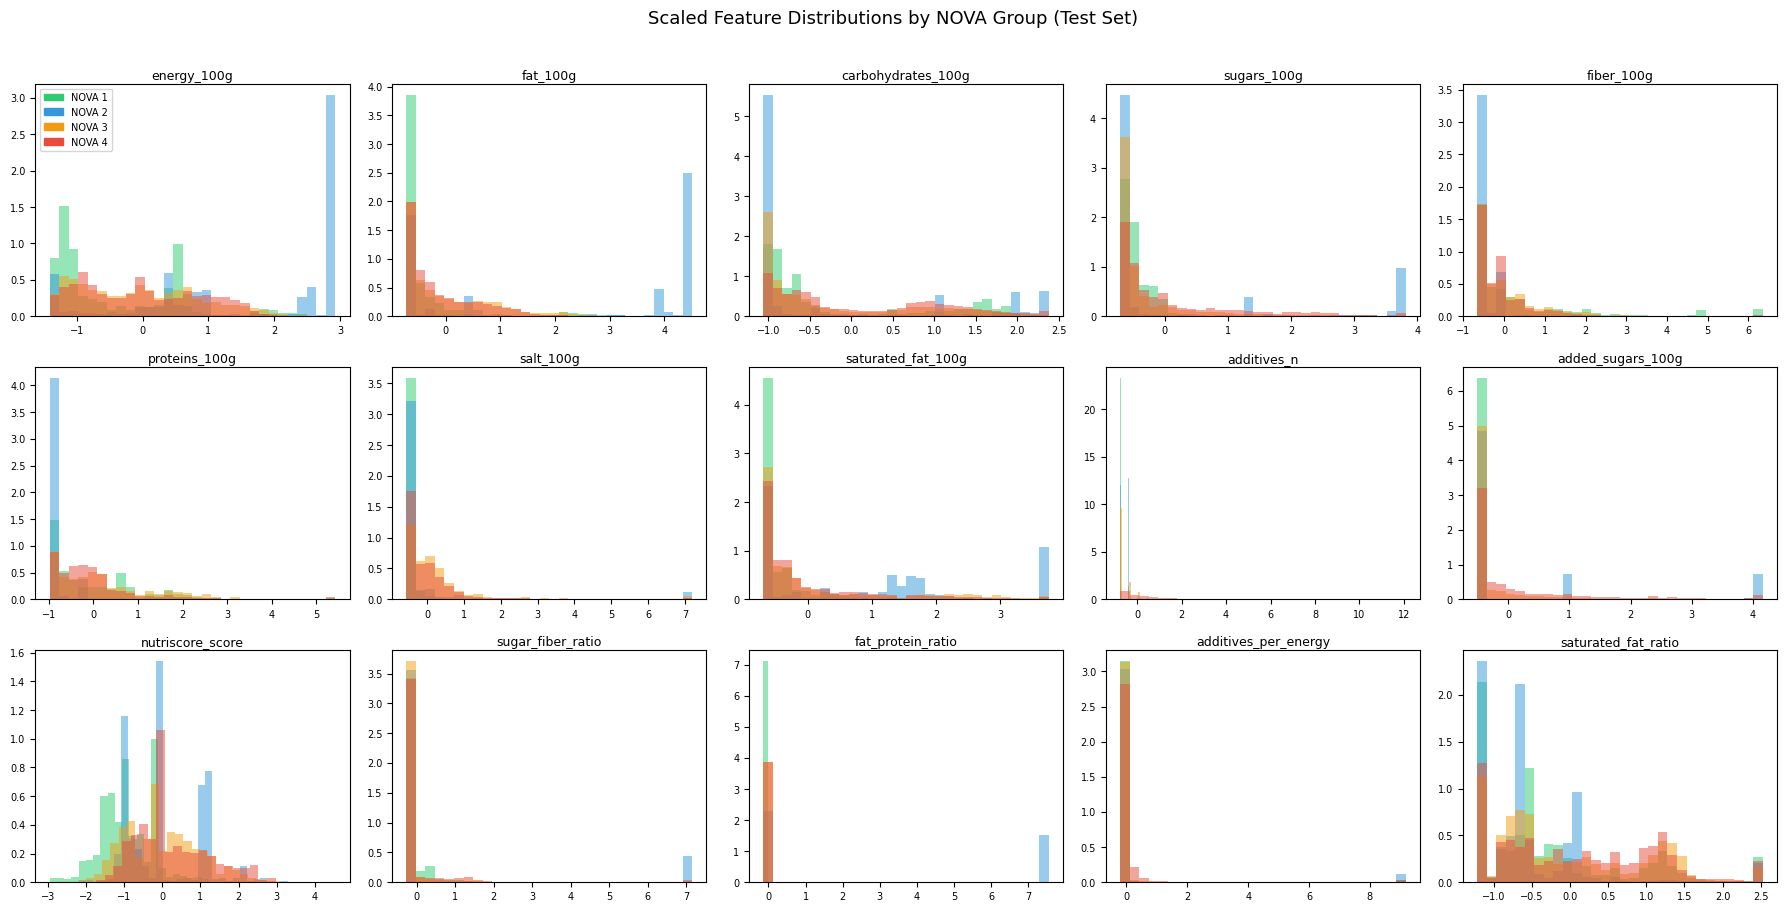

In [6]:
plotter.plot_feature_distributions(X_test_scaled, y_test.values, feature_names)

---
## Model 1: Autoencoder (MLPRegressor Auto-Associative Network)

An **autoencoder** is a neural network trained to reconstruct its own input through a compressed bottleneck representation. When trained on NOVA 1 data only, the network learns a compact encoding of what whole foods look like nutritionally.

**Architecture:** `Input (n_features) → 64 → 32 → 8 (bottleneck) → 32 → 64 → Output (n_features)`

**Anomaly score:** Mean squared error between the original feature vector and its reconstruction. The model reconstructs NOVA 1 patterns accurately but struggles with out-of-distribution NOVA 4 products - resulting in higher reconstruction error for anomalous samples.

**Threshold:** 95th percentile of NOVA 1 *training* reconstruction errors (i.e., products more extreme than 95% of whole foods are flagged).

In [7]:
autoencoder = trainer.train_autoencoder(X_nova1_train)

Training Autoencoder on NOVA 1 samples …
Done in 2.4s  |  iterations: 39  |  best val loss: 0.502900


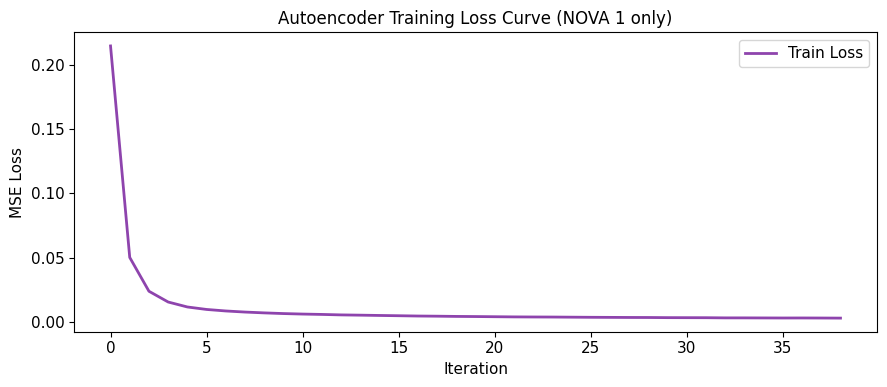

In [8]:
plotter.plot_loss_curve(autoencoder)

In [9]:
# fit threshold on NOVA 1 training errors, then score the full test set
ae_threshold               = scorer.fit_ae_threshold(autoencoder, X_nova1_train)
ae_scores_test, ae_anomalies = scorer.score_autoencoder(autoencoder, X_test_scaled)

Autoencoder anomaly threshold (95th pct of NOVA 1 train errors): 0.030195
Autoencoder — anomalies flagged: 30,904 / 44,759  (69.0%)


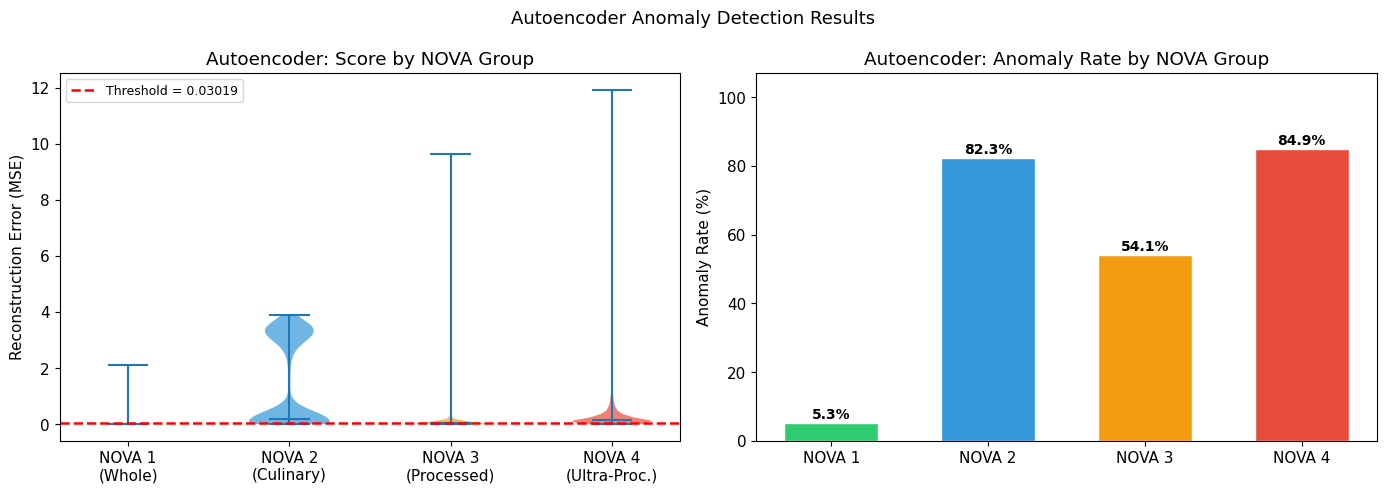

In [10]:
plotter.plot_score_violin_and_rate(
    scores          = ae_scores_test,
    anomalies       = ae_anomalies,
    y_test_0indexed = y_test.values,
    title_prefix    = "Autoencoder",
    score_ylabel    = "Reconstruction Error (MSE)",
    threshold       = ae_threshold,
)

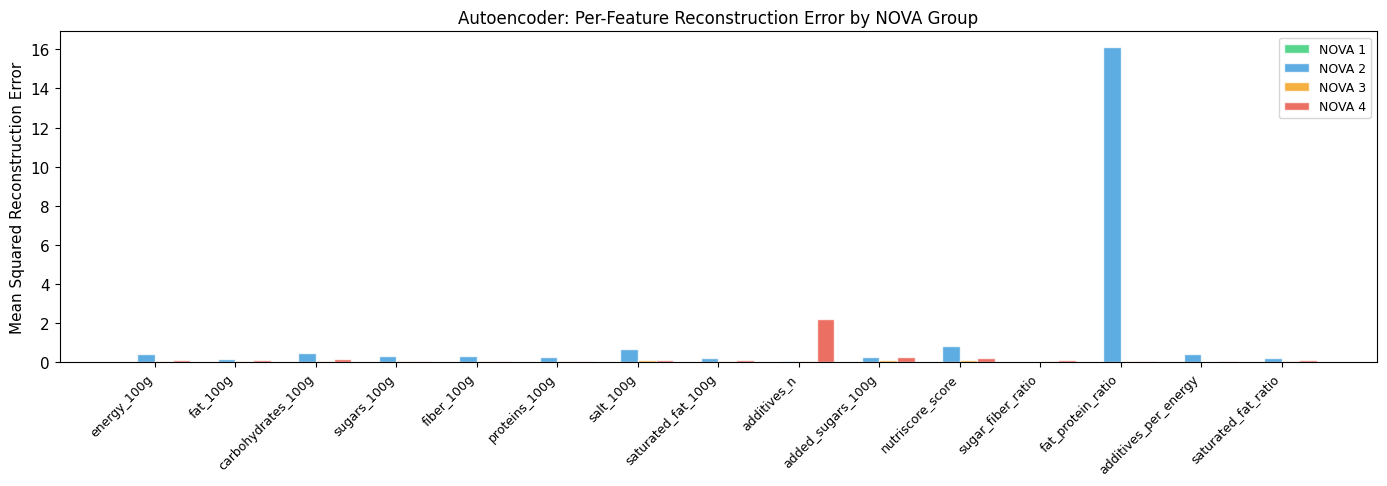

Top 5 features with highest reconstruction error for NOVA 4:
additives_n           2.219129
added_sugars_100g     0.285745
nutriscore_score      0.215053
carbohydrates_100g    0.146761
salt_100g             0.118880


In [11]:
plotter.plot_per_feature_reconstruction_error(
    autoencoder     = autoencoder,
    X_test_scaled   = X_test_scaled,
    y_test_0indexed = y_test.values,
    feature_names   = feature_names,
)

---
## Model 2: Isolation Forest

**Isolation Forest** detects anomalies by recursively partitioning the feature space with random splits. Anomalous points are isolated in **fewer splits** (shorter average path length) because they are sparse and different from the bulk of the training distribution.

**Key advantages:**
- No distance metric required — works well in higher-dimensional spaces
- Efficient: `O(n log n)` training and scoring
- `contamination=0.05` sets the expected fraction of outliers in the NOVA 1 training set

**Anomaly score:** Negated `decision_function` output (higher = more anomalous). The natural threshold is 0: samples with `decision_function < 0` are flagged as anomalies.

In [12]:
iso_forest = trainer.train_isolation_forest(X_nova1_train)

Training Isolation Forest on NOVA 1 samples …
Done in 0.8s  |  n_estimators: 300  |  max_samples per tree: 256


In [13]:
if_scores_test, if_anomalies = scorer.score_isolation_forest(iso_forest, X_test_scaled)

Isolation Forest — anomalies flagged: 27,913 / 44,759  (62.4%)


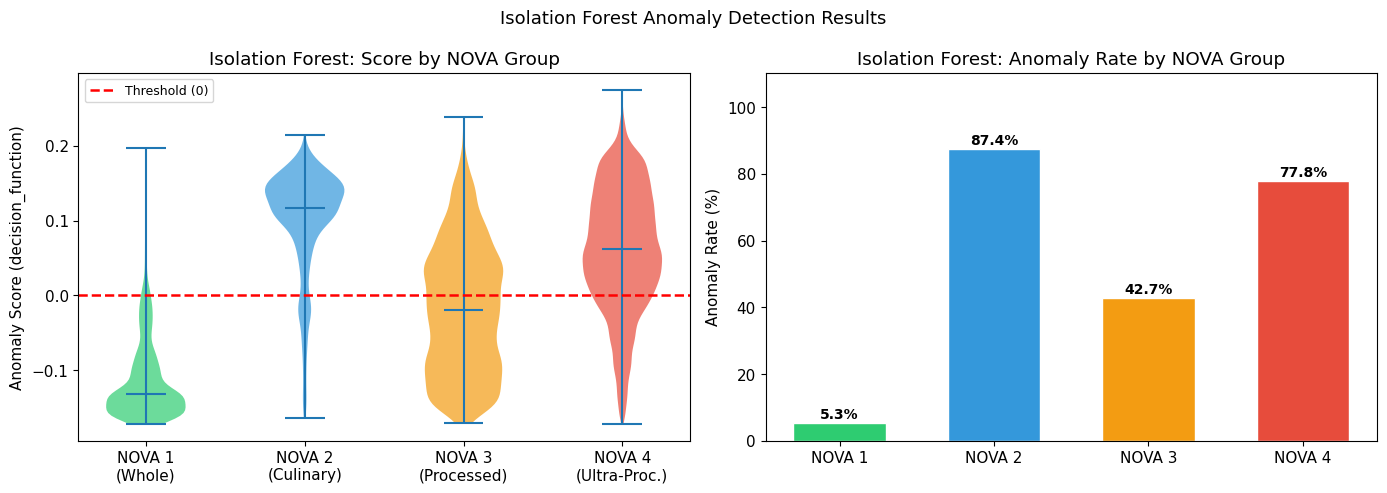

In [14]:
plotter.plot_score_violin_and_rate(
    scores          = if_scores_test,
    anomalies       = if_anomalies,
    y_test_0indexed = y_test.values,
    title_prefix    = "Isolation Forest",
    score_ylabel    = "Anomaly Score (decision_function)",
)

---
## Model 3: One-Class SVM (OCSVM)

**One-Class SVM** maps training data into a high-dimensional feature space via an RBF kernel and finds the maximum-margin hyperplane separating the origin from the data. New samples falling outside this boundary are flagged as anomalies.

In [15]:
oc_svm = trainer.train_one_class_svm(X_nova1_train)

Training One-Class SVM on NOVA 1 samples …
Done in 0.7s  |  kernel: rbf  |  nu: 0.05  |  gamma: scale  |  support vectors: 1,094


In [16]:
svm_scores_test, svm_anomalies = scorer.score_one_class_svm(oc_svm, X_test_scaled)

One-Class SVM — anomalies flagged: 17,385 / 44,759  (38.8%)


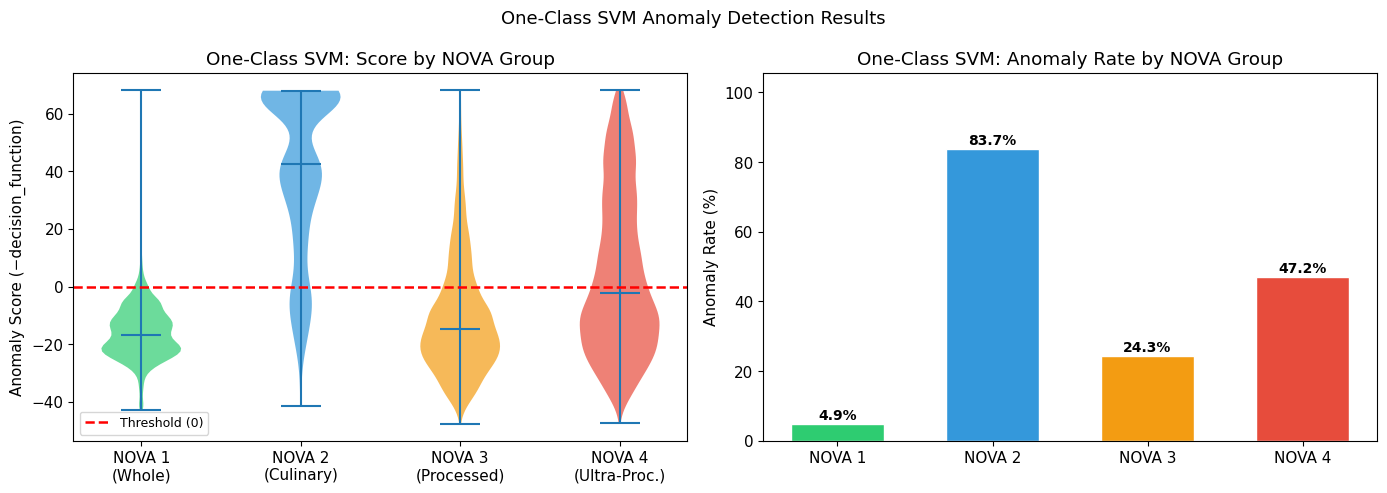

In [17]:
plotter.plot_score_violin_and_rate(
    scores          = svm_scores_test,
    anomalies       = svm_anomalies,
    y_test_0indexed = y_test.values,
    title_prefix    = "One-Class SVM",
    score_ylabel    = "Anomaly Score (−decision_function)",
)

---
## Ensemble: Majority Vote and Score Fusion

Combining all three models reduces the individual false-positive rate and produces a more robust anomaly signal:

- **Binary ensemble (majority vote):** a sample is flagged if **≥ 2 out of 3** models independently flag it as an anomaly
- **Continuous ensemble score:** each model's raw score is MinMax-normalised to [0, 1] over the test batch, then averaged — giving a calibrated 0→1 "distance from whole-food baseline"

In [18]:
flags_df = scorer.build_ensemble(
    ae_anomalies    = ae_anomalies,
    if_anomalies    = if_anomalies,
    svm_anomalies   = svm_anomalies,
    ae_scores       = ae_scores_test,
    if_scores       = if_scores_test,
    svm_scores      = svm_scores_test,
    y_test_0indexed = y_test.values,
)


Ensemble anomaly rates by NOVA group (majority vote ≥ 2/3):
  NOVA 1:   3.7%  (200 / 5,377)
  NOVA 2:  89.4%  (1,469 / 1,643)
  NOVA 3:  39.6%  (3,562 / 8,990)
  NOVA 4:  76.9%  (22,114 / 28,749)

Overall ensemble anomaly rate: 61.1%


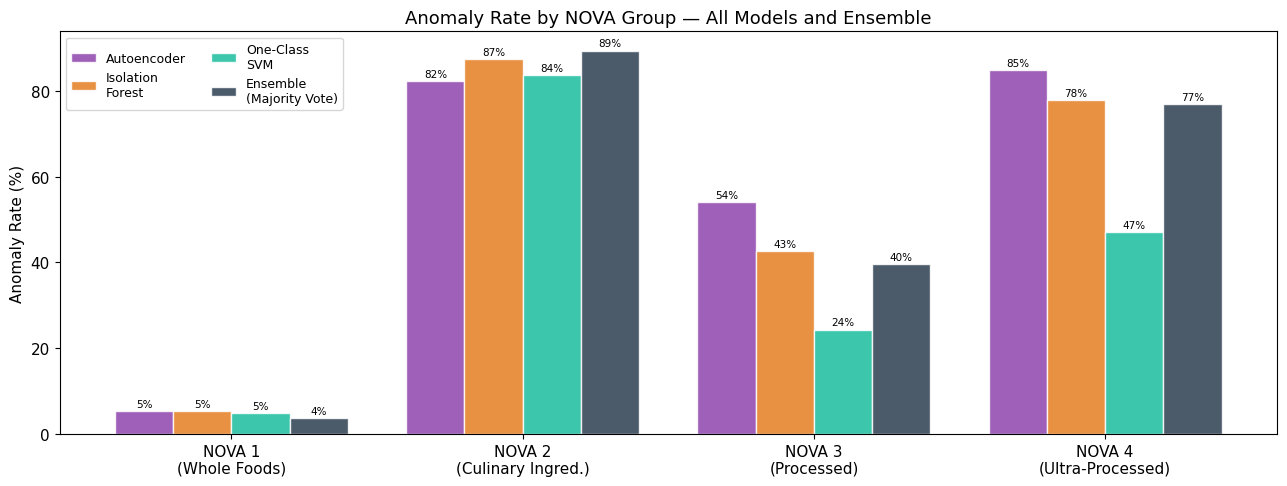

In [19]:
plotter.plot_cross_model_anomaly_rates(
    all_flags       = [ae_anomalies, if_anomalies, svm_anomalies,
                       flags_df["ensemble_anomaly"].values],
    y_test_0indexed = y_test.values,
)

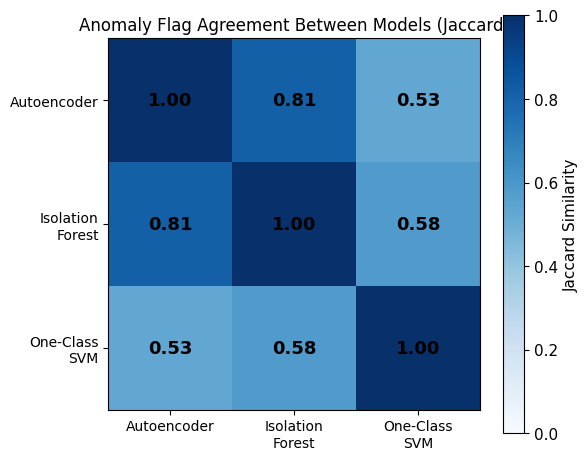

  Autoencoder ∩ Isolation Forest: 26,370 samples flagged by both
  Autoencoder ∩ One-Class SVM: 16,703 samples flagged by both
  Isolation Forest ∩ One-Class SVM: 16,640 samples flagged by both


In [20]:
plotter.plot_jaccard_heatmap(
    binary_flags = [ae_anomalies, if_anomalies, svm_anomalies],
)

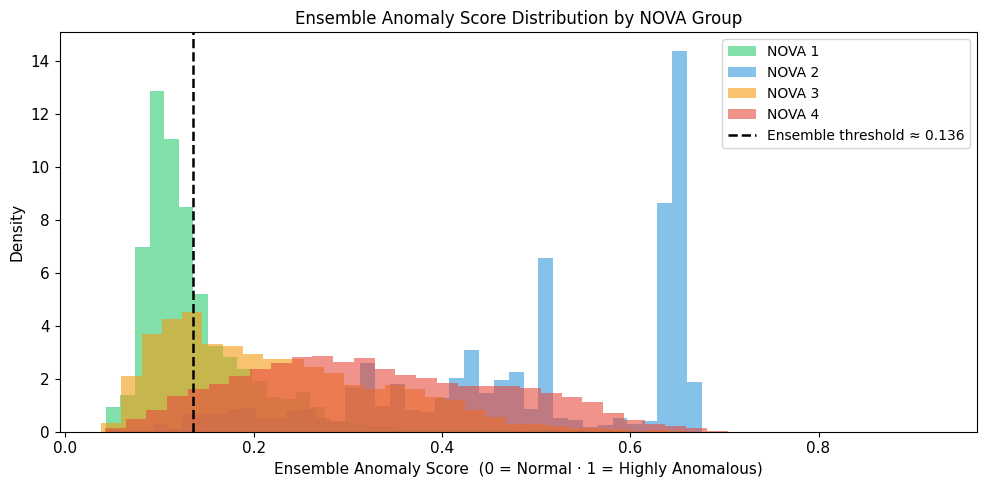

In [21]:
plotter.plot_ensemble_score_distribution(flags_df, y_test.values)

---
## Anomalous Product Analysis

We inspect the top-ranked anomalies from the ensemble to understand *why* they deviate from the whole-food baseline. Comparing mean feature values for 
- NOVA 1 whole foods, 
- the top-20 most anomalous products, and 
- NOVA 4 ultra-processed products reveals which nutritional dimensions drive the anomaly signal.

In [22]:
# Annotated test DataFrame
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
X_test_df["nova_group"]       = y_test.values + 1
X_test_df["ensemble_anomaly"] = flags_df["ensemble_anomaly"].values
X_test_df["ensemble_score"]   = flags_df["ensemble_score"].values
X_test_df["ae_score"]         = ae_scores_test
X_test_df["if_score"]         = if_scores_test
X_test_df["svm_score"]        = svm_scores_test
X_test_df["votes"]            = flags_df["votes"].values

# top-20 anomalous products by ensemble score (all 3 models must agree → votes == 3)
top_20 = X_test_df.sort_values("ensemble_score", ascending=False).head(20)

print("Top 20 most anomalous products — NOVA group distribution:")
print(top_20["nova_group"].value_counts().sort_index().rename("count").to_frame().to_string())
print()
print("Top 10 anomalies (ensemble score + model votes):")
display(top_20[["nova_group", "ensemble_score", "votes", "ae_score", "if_score", "svm_score"]].head(10).round(4))

Top 20 most anomalous products — NOVA group distribution:
            count
nova_group       
3               2
4              18

Top 10 anomalies (ensemble score + model votes):


,nova_group,ensemble_score,votes,ae_score,if_score,svm_score
38473,4,0.9240,3,11.9270,0.1731,68.4124
1409,3,0.8978,3,9.6303,0.2241,68.4004
7869,4,0.8656,3,10.0046,0.1668,68.4124
33348,4,0.8103,3,9.0756,0.1275,68.4111
1729,4,0.7910,3,4.9938,0.2547,68.3941
22516,4,0.7650,3,4.3005,0.2475,67.9251
29494,4,0.7531,3,3.8302,0.2478,68.2854
33003,4,0.7358,3,5.2013,0.1729,68.3761
10898,4,0.7261,3,2.6884,0.2651,65.4899
17573,3,0.7242,3,5.1390,0.1611,68.0185


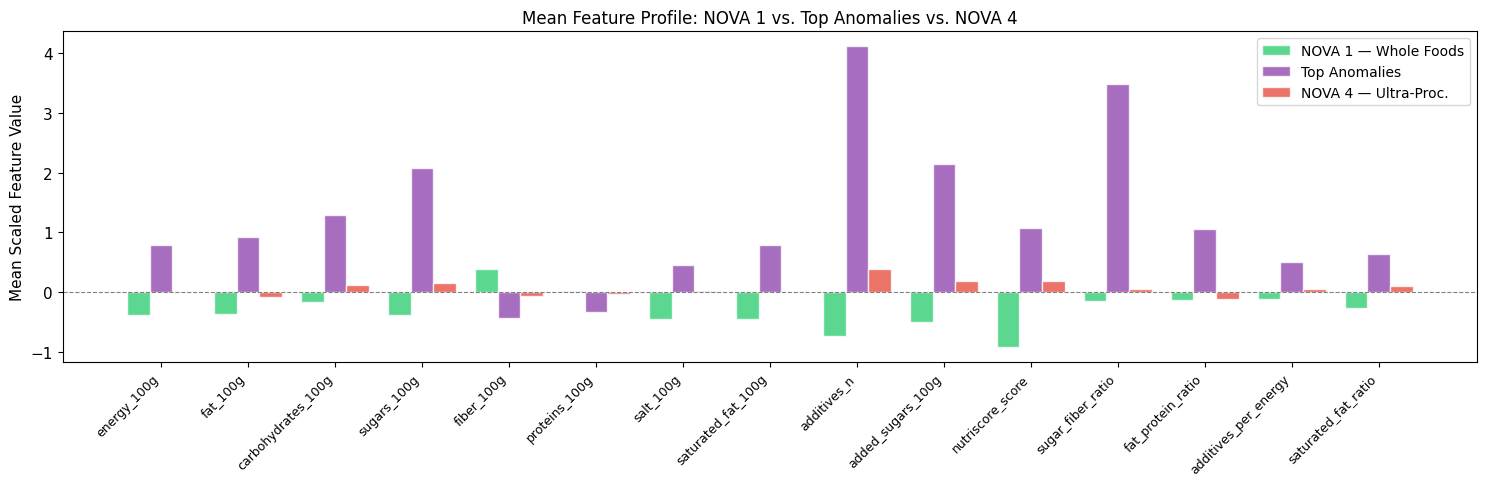


Top 5 features by absolute deviation (Anomaly − NOVA 1):


,Anomaly − NOVA1,NOVA4 − NOVA1
additives_n,4.851,1.121
sugar_fiber_ratio,3.621,0.201
added_sugars_100g,2.641,0.685
sugars_100g,2.472,0.551
nutriscore_score,1.995,1.107


In [23]:
plotter.plot_feature_profile(X_test_df, top_20, feature_names)

---
## Combined Inference: NOVA Classification + Anomaly Detection

This section demonstrates how both use cases operate together in a single inference pipeline. Given raw (unscaled) nutritional feature vectors, the function:
1. Scales the input using the fitted StandardScaler from Notebook 02
2. Predicts the NOVA processing tier and confidence via the XGBoost classifier (Use Case 1)
3. Scores each product with all three anomaly models (Use Case 2)
4. Returns a unified result with the NOVA prediction, per-model anomaly scores, majority-vote anomaly flag, and an ensemble score

In [24]:
# Load the trained NOVA classifier (XGBoost from Notebook 04)
nova_classifier = XGBClassifier()
nova_classifier.load_model(FEATURES_ARTIFACTS_DIRECTORY / "xgb_baseline.json")
print(f"NOVA classifier loaded from {FEATURES_ARTIFACTS_DIRECTORY / 'xgb_baseline.json'}")

NOVA classifier loaded from results\features\xgb_baseline.json


In [25]:
# run combined inference on the full test set using the imported function
combined_df = predict_nova_and_anomaly(
    X_raw            = X_test.values,
    scaler           = scaler,
    nova_classifier  = nova_classifier,
    autoencoder      = autoencoder,
    ae_threshold     = ae_threshold,
    iso_forest       = iso_forest,
    oc_svm           = oc_svm,
)
combined_df["true_nova"] = y_test.values + 1

print("Combined inference results (first 10 rows):")
display(combined_df.head(10))

Combined inference results (first 10 rows):


,nova_pred,nova_confidence,ae_score,if_score,svm_score,ensemble_score,anomaly_votes,is_anomalous,true_nova
0,3,0.6147,0.020006,0.007626,-14.274964,0.2305,1,False,4
1,1,0.9173,0.058762,-0.006805,-29.330728,0.1777,1,False,4
2,1,0.8920,0.002470,-0.130009,-15.794522,0.1230,0,False,1
3,1,0.8298,0.045775,0.012561,-24.203353,0.2065,2,True,4
4,3,0.4117,0.233865,0.151858,14.591143,0.4270,3,True,4
5,1,0.9073,0.002143,-0.142748,-24.369411,0.0889,0,False,1
6,1,0.6365,0.417441,0.114939,17.924006,0.4141,3,True,4
7,1,0.9162,0.016279,-0.044565,-14.911950,0.1897,0,False,4
8,1,0.9218,0.006273,-0.118446,-30.054108,0.0908,0,False,3
9,1,0.9218,0.001717,-0.158230,-21.935550,0.0843,0,False,1


In [26]:
# Summary table: NOVA confidence + anomaly rate by true NOVA group
summary = (
    combined_df.groupby("true_nova")
    .agg(
        n_samples         = ("is_anomalous", "count"),
        anomaly_rate_pct  = ("is_anomalous", lambda x: round(x.mean() * 100, 1)),
        mean_ens_score    = ("ensemble_score", lambda x: round(x.mean(), 4)),
        mean_nova_conf    = ("nova_confidence", lambda x: round(x.mean(), 4)),
        nova_correct_pct  = ("nova_pred",
                             lambda x: round((x == combined_df.loc[x.index, "true_nova"]).mean() * 100, 1)),
    )
    .rename(index={g: f"NOVA {g}" for g in range(1, 5)})
    .rename(columns={
        "n_samples":        "N Samples",
        "anomaly_rate_pct": "Anomaly Rate (%)",
        "mean_ens_score":   "Mean Ensemble Score",
        "mean_nova_conf":   "Mean NOVA Confidence",
        "nova_correct_pct": "NOVA Accuracy (%)",
    })
)

print("Combined Inference Summary by True NOVA Group")
display(summary)

Combined Inference Summary by True NOVA Group


,N Samples,Anomaly Rate (%),Mean Ensemble Score,Mean NOVA Confidence,NOVA Accuracy (%)
true_nova,,,,,
NOVA 1,5377,3.7,0.1387,0.8875,97.2
NOVA 2,1643,89.4,0.4912,0.7450,0.1
NOVA 3,8990,39.6,0.2243,0.7853,28.8
NOVA 4,28749,76.9,0.3287,0.7208,23.6


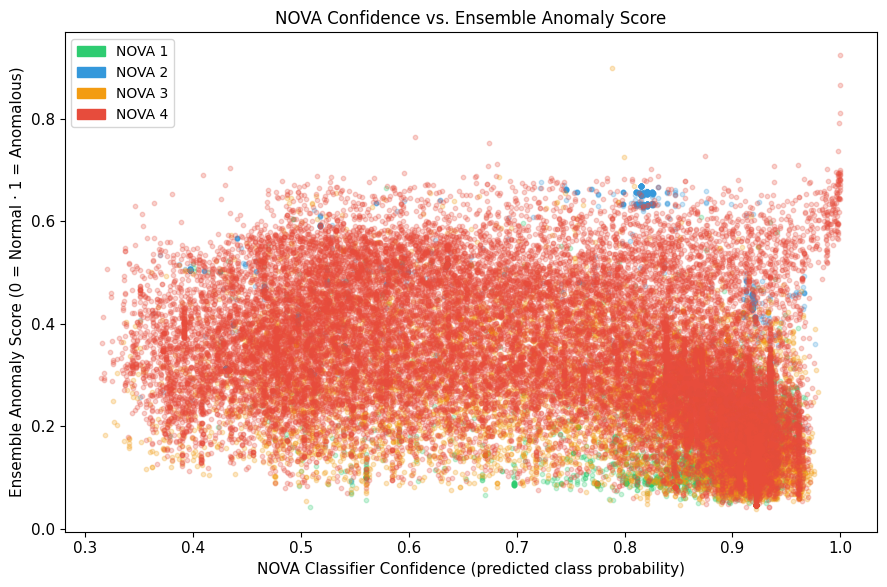

In [27]:
plotter.plot_confidence_vs_anomaly_score(combined_df)

---
## Save Artifacts


In [28]:
# export anomaly models to backend/models for API consumption
API_MODEL_RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Exporting anomaly detection artifacts to backend/models for API...")

# save all trained anomaly models and metadata in a single joblib file
anomaly_artifact = {
    "autoencoder":      autoencoder,              # MLPRegressor auto-associative network
    "isolation_forest": iso_forest,               # IsolationForest (contamination=0.05)
    "one_class_svm":    oc_svm,                   # OneClassSVM (rbf, nu=0.05)
    "ae_threshold":     float(ae_threshold),      # 95th percentile of NOVA 1 train errors
    "ae_train_errors":  scorer.ae_train_errors,   # NOVA 1 training reconstruction errors
    "feature_names":    feature_names,            # column order for inference
    "nova1_train_size": int(X_nova1_train.shape[0]),
    "features": {
        "total_count": len(feature_names),
        "original_features": fe_meta["original_features"],
        "engineered_features": fe_meta["engineered_features"],
        "removed_features": fe_meta["features_removed_in_eda"],
    },
}
artifact_path = API_MODEL_RESULTS_DIRECTORY / "anomaly_models.joblib"
joblib.dump(anomaly_artifact, artifact_path)
print(f"Saved: {artifact_path}")

# save test-set anomaly scores as a parquet for downstream analysis
ANOMALY_DETECTION_ARTIFACTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
scores_out = pd.DataFrame({
    "nova_group":       y_test.values + 1,
    "ae_score":         ae_scores_test,
    "if_score":         if_scores_test,
    "svm_score":        svm_scores_test,
    "ae_anomaly":       ae_anomalies,
    "if_anomaly":       if_anomalies,
    "svm_anomaly":      svm_anomalies,
    "ensemble_score":   flags_df["ensemble_score"].values,
    "ensemble_anomaly": flags_df["ensemble_anomaly"].values,
    "anomaly_votes":    flags_df["votes"].values,
})
scores_path = ANOMALY_DETECTION_ARTIFACTS_DIRECTORY / "anomaly_scores_test.parquet"
scores_out.to_parquet(scores_path, index=False)
print(f"Saved: {scores_path}")

Exporting anomaly detection artifacts to backend/models for API...
Saved: backend\models\anomaly_models.joblib
Saved: results\anomaly_detection\anomaly_scores_test.parquet
